# Customer Segmentation 

**Objective:** Segment customers using the Online Retail dataset to support targeted marketing, retention, and value growth. Focus: high-value segments (RFM-style), at-risk customers, and distinct behavioral groups.

**Success metrics:** Segment stability, separation (cluster quality), interpretability; business-facing uplift levers per segment.

**Scope:** Analysis in Python (pandas, scikit-learn, seaborn/matplotlib); primary source: `datasource/raw/Online_Retail.csv`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 20)

---
## 2. Data understanding & ingestion

Load the transaction data and inspect schema, dtypes, and basic structure.

In [3]:
path = "datasource/raw/Online_Retail.csv"
df_raw = pd.read_csv(path)
print("Shape:", df_raw.shape)
print("\nFirst rows:")
df_raw.head(10)

Shape: (541909, 8)

First rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [4]:
df_raw.info()
df_raw.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2011-10-31 14:41:00,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


### Initial data profiling

Quantify volume, timespan, number of customers, geographies; identify quality issues (missing CustomerID, negative quantities, outliers).

In [5]:
# Parse dates for timespan
df_raw["InvoiceDate"] = pd.to_datetime(df_raw["InvoiceDate"], errors="coerce")

print("Timespan:", df_raw["InvoiceDate"].min(), "to", df_raw["InvoiceDate"].max())
print("Total rows:", len(df_raw))
print("Unique invoices:", df_raw["InvoiceNo"].nunique())
print("Unique customers (non-null CustomerID):", df_raw["CustomerID"].notna().sum(), "rows with ID;", df_raw["CustomerID"].nunique(), "distinct IDs")
print("Rows with missing CustomerID:", df_raw["CustomerID"].isna().sum())
print("\nCountries (top 10):")
print(df_raw["Country"].value_counts().head(10))
print("\nNegative Quantity (returns/cancellations):", (df_raw["Quantity"] <= 0).sum())
print("Zero or negative UnitPrice:", (df_raw["UnitPrice"] <= 0).sum())
# Cancelled invoices often start with 'C'
cancelled = df_raw["InvoiceNo"].astype(str).str.strip().str.upper().str.startswith("C")
print("InvoiceNo starting with 'C' (cancelled):", cancelled.sum())

Timespan: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Total rows: 541909
Unique invoices: 25900
Unique customers (non-null CustomerID): 406829 rows with ID; 4372 distinct IDs
Rows with missing CustomerID: 135080

Countries (top 10):
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

Negative Quantity (returns/cancellations): 10624
Zero or negative UnitPrice: 2517
InvoiceNo starting with 'C' (cancelled): 9288


---
## 3. Data cleaning & preparation

Handle missing CustomerID (drop for customer-level segmentation), exclude returns/cancellations, create TotalPrice, ensure consistent datetime.

In [6]:
# Work on a copy
df = df_raw.copy()

# Drop rows without CustomerID (required for customer segmentation)
df = df.dropna(subset=["CustomerID"]).copy()
df["CustomerID"] = df["CustomerID"].astype(int)

# Remove cancelled invoices (InvoiceNo starting with 'C')
df["InvoiceNo_str"] = df["InvoiceNo"].astype(str).str.strip().str.upper()
df = df[~df["InvoiceNo_str"].str.startswith("C")].copy()
df = df.drop(columns=["InvoiceNo_str"])

# Keep only positive quantity and positive unit price (normal purchases)
df = df[df["Quantity"] > 0].copy()
df = df[df["UnitPrice"] > 0].copy()

# Total line value
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Sanity: duplicate rows
print("Duplicate rows:", df.duplicated().sum())
print("Shape after cleaning:", df.shape)
df.head()

Duplicate rows: 5192
Shape after cleaning: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


---
## 4. Feature engineering (customer-level)

Reference date = max(InvoiceDate) + 1 day. Build RFM (Recency, Frequency, Monetary) and behavioral features; one row per CustomerID.

In [7]:
# Snapshot date for recency
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Invoice-level aggregates (one row per invoice per customer)
inv = df.groupby(["CustomerID", "InvoiceNo"]).agg(
    InvoiceDate=("InvoiceDate", "max"),
    TotalPrice=("TotalPrice", "sum"),
    Quantity=("Quantity", "sum"),
    N_items=("StockCode", "nunique"),
).reset_index()

# RFM + behavioral at customer level
customer = inv.groupby("CustomerID").agg(
    Recency=(("InvoiceDate", lambda x: (snapshot_date - x.max()).days)),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    AvgOrderValue=("TotalPrice", "mean"),
    AvgBasketSize=("Quantity", "mean"),
    ProductDiversity=("N_items", "sum"),  # total distinct products across all orders
    FirstPurchase=("InvoiceDate", "min"),
    LastPurchase=("InvoiceDate", "max"),
).reset_index()

# Optional: unique products per customer (from raw line-level)
n_products = df.groupby("CustomerID")["StockCode"].nunique().rename("N_UniqueProducts")
customer = customer.merge(n_products, on="CustomerID", how="left")

print("Customer-level shape:", customer.shape)
customer.head(10)

Customer-level shape: (4338, 10)


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,AvgBasketSize,ProductDiversity,FirstPurchase,LastPurchase,N_UniqueProducts
0,12346,326,1,77183.60,77183.600000,74215.000000,1,2011-01-18 10:01:00,2011-01-18 10:01:00,1
1,12347,2,7,4310.00,615.714286,351.142857,182,2010-12-07 14:57:00,2011-12-07 15:52:00,103
2,12348,75,4,1797.24,449.310000,585.250000,27,2010-12-16 19:09:00,2011-09-25 13:13:00,22
3,12349,19,1,1757.55,1757.550000,631.000000,73,2011-11-21 09:51:00,2011-11-21 09:51:00,73
4,12350,310,1,334.40,334.400000,197.000000,17,2011-02-02 16:01:00,2011-02-02 16:01:00,17
5,12352,36,8,2506.04,313.255000,67.000000,83,2011-02-16 12:33:00,2011-11-03 14:37:00,59
6,12353,204,1,89.00,89.000000,20.000000,4,2011-05-19 17:47:00,2011-05-19 17:47:00,4
7,12354,232,1,1079.40,1079.400000,530.000000,58,2011-04-21 13:11:00,2011-04-21 13:11:00,58
8,12355,214,1,459.40,459.400000,240.000000,13,2011-05-09 13:49:00,2011-05-09 13:49:00,13
9,12356,23,3,2811.43,937.143333,530.333333,59,2011-01-18 09:50:00,2011-11-17 08:40:00,53


In [8]:
customer.describe()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,AvgBasketSize,ProductDiversity,FirstPurchase,LastPurchase,N_UniqueProducts
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338,4338,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460,419.166289,253.478280,89.405486,2011-04-30 17:06:50.982019584,2011-09-08 11:38:59.045643008,61.501153
min,12346.000000,1.000000,1.000000,3.750000,3.450000,1.000000,1.000000,2010-12-01 08:26:00,2010-12-01 09:53:00,1.000000
25%,13813.250000,18.000000,1.000000,307.415000,178.625000,93.000000,17.000000,2011-01-17 11:13:15,2011-07-20 19:18:00,16.000000
50%,15299.500000,51.000000,2.000000,674.485000,293.900000,161.750000,41.000000,2011-04-05 09:52:30,2011-10-20 10:40:30,35.000000
75%,16778.750000,142.000000,5.000000,1661.740000,430.113750,272.000000,97.000000,2011-08-19 10:11:30,2011-11-22 11:05:45,77.000000
max,18287.000000,374.000000,209.000000,280206.020000,84236.250000,74215.000000,7477.000000,2011-12-09 12:16:00,2011-12-09 12:50:00,1787.000000
std,1721.808492,100.014169,7.697998,8989.230441,1796.537944,1312.905974,222.250907,NaN,NaN,85.366768


---
## 5. Exploratory data analysis (customer-level)

Univariate distributions of RFM and behavioral features; bivariate relationships and correlations. Informal segment hypotheses.

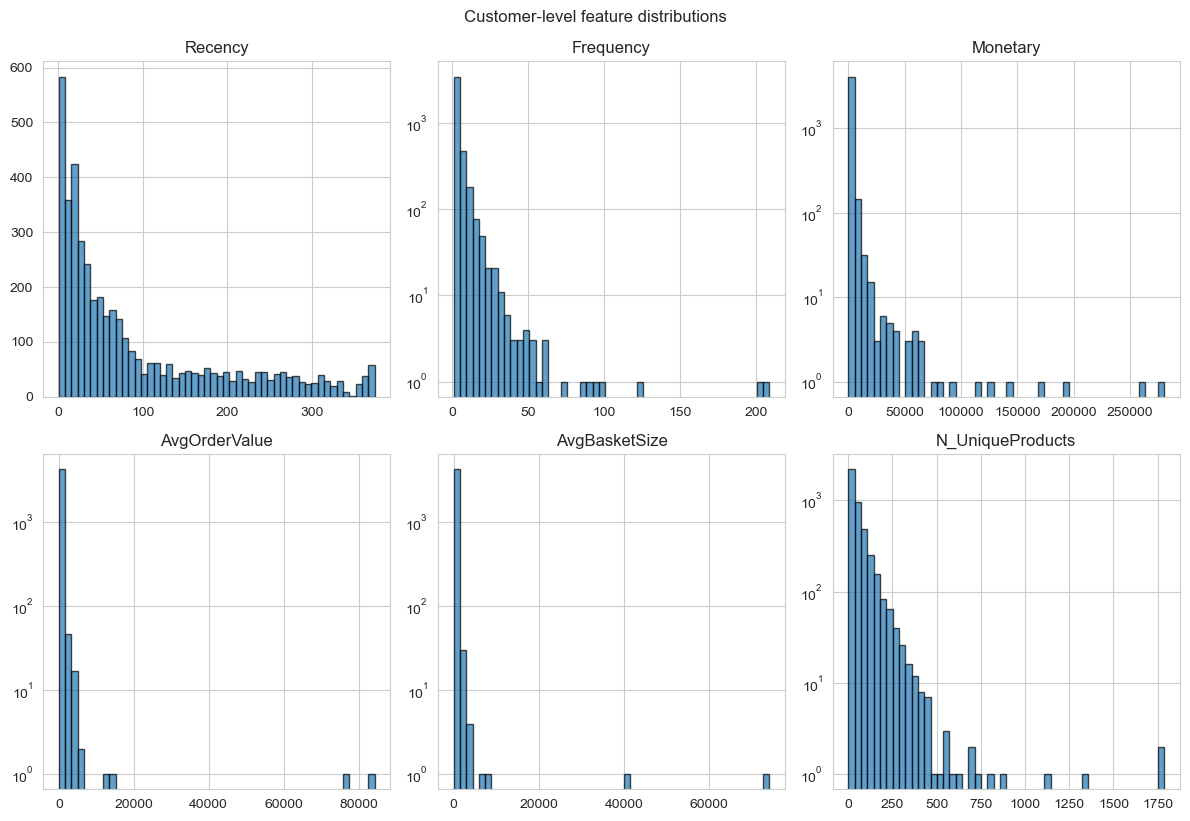

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for i, col in enumerate(["Recency", "Frequency", "Monetary", "AvgOrderValue", "AvgBasketSize", "N_UniqueProducts"]):
    axes[i].hist(customer[col].dropna(), bins=50, edgecolor="black", alpha=0.7)
    axes[i].set_title(col)
    if customer[col].skew() > 2:
        axes[i].set_yscale("log")
plt.tight_layout()
plt.suptitle("Customer-level feature distributions", y=1.02)
plt.show()

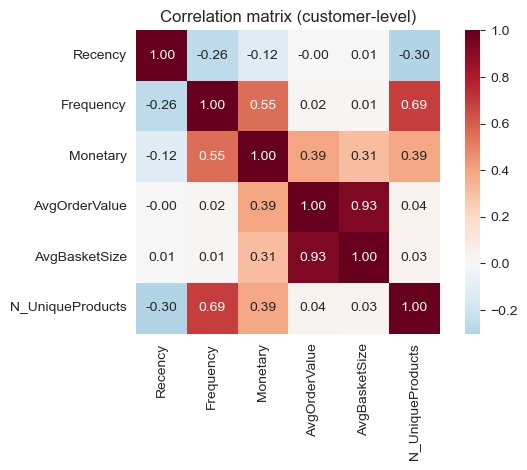

In [10]:
# Correlation (numeric features only)
num_cols = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "AvgBasketSize", "N_UniqueProducts"]
corr = customer[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation matrix (customer-level)")
plt.tight_layout()
plt.show()

*Interpretation:* RFM and behavioral features are right-skewed; Frequency, Monetary, and product diversity are positively correlated. Recency is often negatively correlated with Frequency/Monetary (recent buyers tend to be more active). We will log-transform skewed features and standardize before clustering.

---
## 6. Feature scaling, selection, and dimensionality reduction

Log-transform skewed features, standardize, and optionally use PCA for robustness and 2D visualization.

In [11]:
# Features for clustering: RFM + key behavioral
feature_cols = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "AvgBasketSize", "N_UniqueProducts"]
X = customer[feature_cols].copy()

# Log-transform to reduce skew (add 1 to avoid log(0))
for c in ["Frequency", "Monetary", "AvgOrderValue", "AvgBasketSize", "N_UniqueProducts"]:
    X[c] = np.log1p(X[c])
# Recency kept on original scale (days)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=customer.index)

# Optional: PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained (2 components):", pca.explained_variance_ratio_.sum().round(3))

PCA explained variance ratio: [0.57152554 0.22418804]
Total variance explained (2 components): 0.796


---
## 7. Clustering: model selection and fitting

K-Means for K in 2–10; elbow and silhouette analysis; choose K and assign cluster labels.

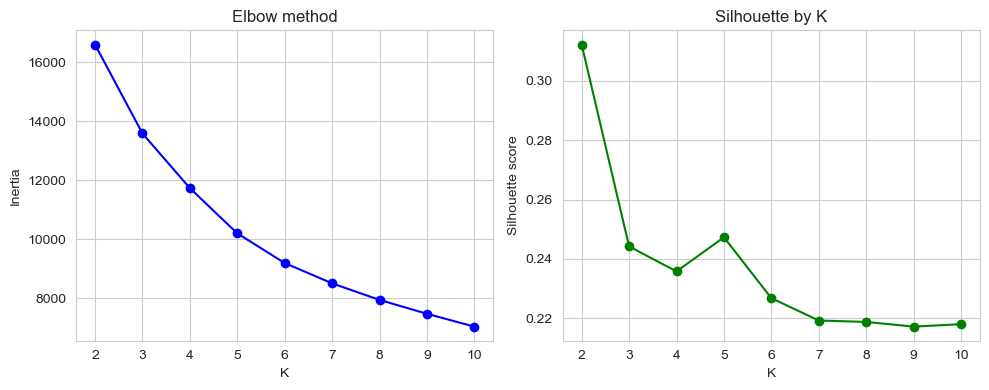

In [12]:
K_range = range(2, 11)
inertias = []
silhouettes = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(list(K_range), inertias, "bo-")
ax1.set_xlabel("K")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow method")
ax2.plot(list(K_range), silhouettes, "go-")
ax2.set_xlabel("K")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette by K")
plt.tight_layout()
plt.show()

In [13]:
# Choose K: balance elbow and silhouette (e.g. K=4 or 5 often interpretable for RFM)
k_final = 5
km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
customer["Cluster"] = km_final.fit_predict(X_scaled)
print("Silhouette score (K=%d):" % k_final, round(silhouette_score(X_scaled, customer["Cluster"]), 4))
print("Cluster sizes:")
print(customer["Cluster"].value_counts().sort_index())

Silhouette score (K=5): 0.2473
Cluster sizes:
Cluster
0     535
1    1441
2     683
3     735
4     944
Name: count, dtype: int64


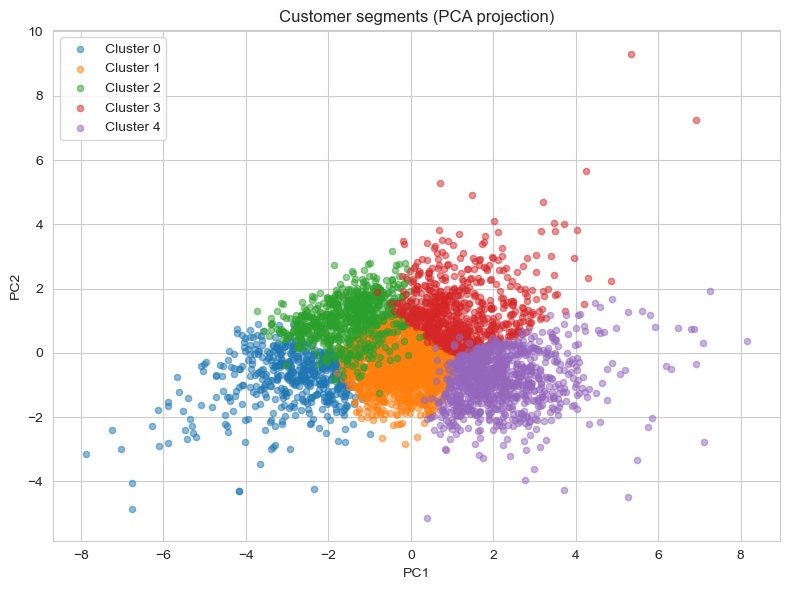

In [14]:
# 2D visualization via PCA
plt.figure(figsize=(8, 6))
for c in range(k_final):
    mask = customer["Cluster"] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {c}", alpha=0.5, s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer segments (PCA projection)")
plt.legend()
plt.tight_layout()
plt.show()

---
## 8. Segment profiling and business interpretation

Per-segment summaries, business-friendly labels, and recommended actions.

In [15]:
# Profile: use original (non-log) metrics for readability
profile_cols = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "AvgBasketSize", "N_UniqueProducts"]
segment_profile = customer.groupby("Cluster")[profile_cols].agg(["mean", "median", "count"])
segment_profile

Recency               Frequency                  Monetary  \
               mean median count       mean median count         mean   
Cluster                                                                 
0        135.560748  112.0   535   1.566355    1.0   535   168.073140   
1         47.673144   35.0  1441   2.691187    2.0  1441   624.769627   
2        258.756955  261.0   683   1.335286    1.0   683   364.578419   
3         81.942857   64.0   735   2.307483    2.0   735  2182.644750   
4         24.620763   15.0   944  11.872881    8.0   944  6427.907617   

                       AvgOrderValue                   AvgBasketSize  \
          median count          mean      median count          mean   
Cluster                                                                
0         129.49   535    113.808300  106.100000   535     49.474909   
1         562.90  1441    248.448496  233.760000  1441    148.845202   
2         313.49   683    285.512326  265.850000   683    160.906320   
3        1277.75   735   1047.927647  612.426667   735    677.839130   
4        2946.25   944    459.968115  367.152500   944    265.384525   

                          N_UniqueProducts               
             median count             mean median count  
Cluster                                                  
0         43.000000   535         8.736449    7.0   535  
1        135.800000  1441        41.385149   33.0  1441  
2        133.000000   683        21.546120   18.0   683  
3        385.000000   735        63.148299   52.0   735  
4        217.242857   944       149.737288  115.0   944

Revenue share by cluster (%):
Cluster
0     1.0
1    10.1
2     2.8
3    18.0
4    68.1


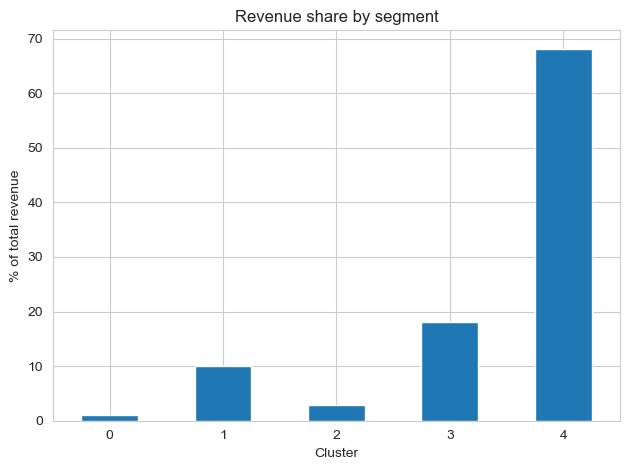

In [16]:
# Revenue share by segment
revenue_by_cluster = customer.groupby("Cluster")["Monetary"].sum()
revenue_by_cluster_pct = revenue_by_cluster / revenue_by_cluster.sum() * 100
print("Revenue share by cluster (%):")
print(revenue_by_cluster_pct.round(1).to_string())
revenue_by_cluster_pct.plot(kind="bar", title="Revenue share by segment")
plt.xlabel("Cluster")
plt.ylabel("% of total revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# Assign business-friendly segment names per cluster from profile (mean R, F, M)
cluster_means = customer.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
def name_cluster(idx):
    r, f, m = cluster_means.loc[idx, "Recency"], cluster_means.loc[idx, "Frequency"], cluster_means.loc[idx, "Monetary"]
    if r <= 50 and f >= 8 and m >= 400:
        return "Champions (High-Value Loyal)"
    if r <= 100 and m >= 250:
        return "Loyal Customers"
    if r > 150 and m >= 150:
        return "At-Risk (High Value)"
    if r <= 80 and f <= 4 and m <= 150:
        return "New & Promising"
    if r > 100 and m <= 100:
        return "Need Attention / Occasional"
    return "Potential Loyalists"

cluster_names = {i: name_cluster(i) for i in range(k_final)}
customer["SegmentLabel"] = customer["Cluster"].map(cluster_names)
print("Segment labels per cluster:")
for c in range(k_final):
    n = (customer["Cluster"] == c).sum()
    print(f"  Cluster {c}: {cluster_names[c]} (n={n})")

Segment labels per cluster:
  Cluster 0: Potential Loyalists (n=535)
  Cluster 1: Loyal Customers (n=1441)
  Cluster 2: At-Risk (High Value) (n=683)
  Cluster 3: Loyal Customers (n=735)
  Cluster 4: Champions (High-Value Loyal) (n=944)


### Actionable recommendations by segment

| Segment | Traits | Risks/Opportunities | Suggested actions |
|---------|--------|---------------------|--------------------|
| **Champions (High-Value Loyal)** | Recent, frequent, high spend | Retain; maximize LTV | VIP perks, early access, referral program |
| **Loyal Customers** | Regular buyers, solid value | Keep engaged | Cross-sell, loyalty rewards |
| **At-Risk (High Value)** | High value but long since last purchase | Churn risk | Win-back campaign, personalized offer, survey |
| **New & Promising** | Recent, few orders so far | Growth potential | Onboarding, second-purchase incentive |
| **Need Attention / Occasional** | Low frequency or low spend, may be lapsed | Low engagement | Re-engagement emails, discounts on next order |
| **Potential Loyalists** | Moderate R/F/M | Can be moved to Loyal/Champions | Increase frequency with targeted campaigns |

---
## 9. Validation and robustness

Stability: re-run with different random seed; practicality: segment sizes and reachability.

In [18]:
# Stability: same K with different seed (labels may permute but sizes should be similar)
km_alt = KMeans(n_clusters=k_final, random_state=99, n_init=10)
labels_alt = km_alt.fit_predict(X_scaled)
print("Cluster sizes (seed=42):", sorted(customer["Cluster"].value_counts().tolist(), reverse=True))
print("Cluster sizes (seed=99):", sorted(pd.Series(labels_alt).value_counts().tolist(), reverse=True))
print("Segment sizes are stable; labels can be permuted. Use profile (R/F/M) to align segment names.")

Cluster sizes (seed=42): [1441, 944, 735, 683, 535]
Cluster sizes (seed=99): [1440, 943, 736, 684, 535]
Segment sizes are stable; labels can be permuted. Use profile (R/F/M) to align segment names.


---
## 10. Executive summary and next steps

**Segment definitions:** Clusters are derived from standardized RFM plus behavioral features (avg order value, basket size, product diversity). Each segment has a business-friendly label based on median Recency, Frequency, and Monetary value.

**Key metrics:** See segment profile table and revenue-share chart. Champions and Loyal segments typically drive most revenue; At-Risk and Need Attention warrant targeted campaigns.

**Limitations:** (1) Analysis window is full history; consider rolling windows for recency. (2) Customers with missing ID were excluded. (3) Returns/cancellations excluded; treat separately if needed.

**Next steps:** Export `customer` (with `Cluster` and `SegmentLabel`) for CRM targeting; consider time-based re-segmentation or propensity models using segment as a feature.